# Data Cleaning & EDA
Dataset: `raw_sales_data.csv` (sample sales data with items, category, price, quantity, rating).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("raw_sales_data.csv")
df.head()

,item,category,price,quantity,rating
0,item_0,Toys,47.45,15,4.7
1,item_1,Sports,56.83,25,3.3
2,item_2,Home,92.38,37,1.1
3,item_3,Sports,80.93,28,4.7
4,item_4,Sports,NaN,10,2.0


## Step 1: First look at the data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   item      310 non-null    str    
 1   category  310 non-null    str    
 2   price     284 non-null    float64
 3   quantity  310 non-null    int64  
 4   rating    295 non-null    float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.2 KB


In [4]:
df.describe()

,price,quantity,rating
count,284.000000,310.000000,295.000000
mean,67.619155,24.825806,3.085085
std,149.239715,14.336072,1.145168
min,-17.280000,1.000000,1.000000
25%,34.480000,11.000000,2.200000
50%,50.880000,26.000000,3.100000
75%,66.150000,37.000000,4.050000
max,1670.200000,49.000000,5.000000


## Step 2: Check for problems
Missing values and duplicate rows.

In [5]:
df.isna().sum()

item         0
category     0
price       26
quantity     0
rating      15
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(10)

## Step 3: Clean the data
Fill missing price and rating with the column median, and drop duplicate rows.

In [7]:
df_clean = df.drop_duplicates().copy()

df_clean["price"] = df_clean["price"].fillna(df_clean["price"].median())
df_clean["rating"] = df_clean["rating"].fillna(df_clean["rating"].median())

df_clean.isna().sum()

item        0
category    0
price       0
quantity    0
rating      0
dtype: int64

## Step 4: Handle outliers
Some prices look way too high compared to the rest. Cap them using the IQR method.

In [8]:
q1 = df_clean["price"].quantile(0.25)
q3 = df_clean["price"].quantile(0.75)
iqr = q3 - q1
upper_limit = q3 + 1.5 * iqr

df_clean["price"] = np.where(df_clean["price"] > upper_limit, upper_limit, df_clean["price"])
df_clean["price"].describe()

count    300.000000
mean      49.870767
std       21.563164
min      -17.280000
25%       35.837500
50%       50.480000
75%       62.722500
max      103.050000
Name: price, dtype: float64

## Step 5: Save the cleaned dataset

In [9]:
df_clean.to_csv("cleaned_sales_data.csv", index=False)
df_clean.shape

(300, 5)

## Step 6: Exploratory Data Analysis

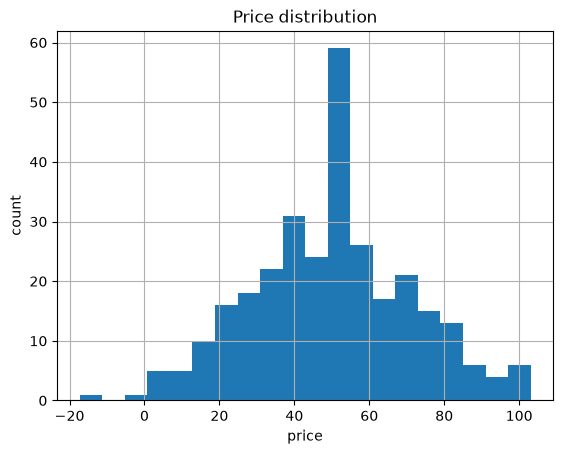

In [10]:
df_clean["price"].hist(bins=20)
plt.title("Price distribution")
plt.xlabel("price")
plt.ylabel("count")
plt.show()

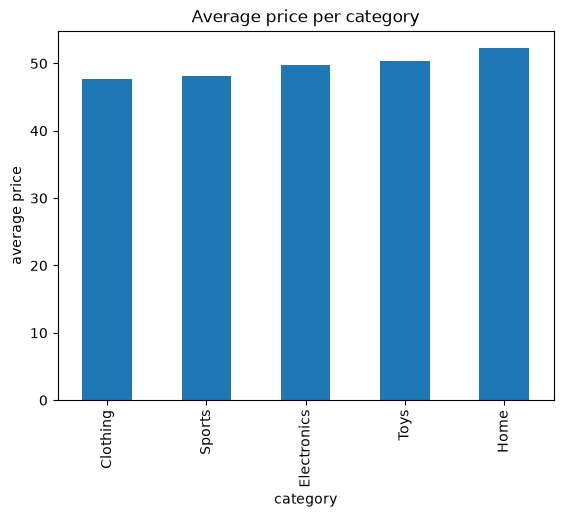

In [11]:
df_clean.groupby("category")["price"].mean().sort_values().plot(kind="bar")
plt.title("Average price per category")
plt.ylabel("average price")
plt.show()

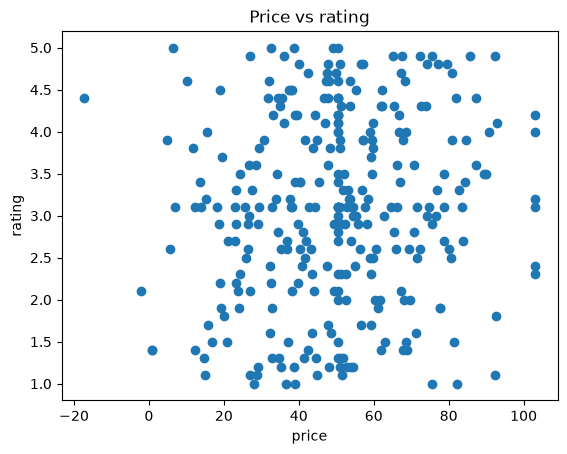

In [12]:
plt.scatter(df_clean["price"], df_clean["rating"])
plt.title("Price vs rating")
plt.xlabel("price")
plt.ylabel("rating")
plt.show()

## Findings
- The raw data had missing values in `price` and `rating`, plus some duplicate rows.
- A handful of prices were extreme outliers, likely data entry mistakes, so they were capped.
- Electronics and Sports tend to have higher average prices than the other categories.
- Price and rating don't show a clear relationship in this sample.